1. B&B run for prmoting decision making

In [ ]:
import sys

class VRP4VansStrictBnB:
    def __init__(self):
        # 1. SETUP DATA
        # Location names
        self.loc_names = [
            "Warehouse (W)",      # 0
            "Luton Airport (LAT)",# 1
            "Uni Bedford (UoB)",  # 2
            "Retail Park (LRP)",  # 3
            "Cap. Green (CGB)",   # 4
            "Hospital (LDHS)",    # 5
            "Town Centre (LTC)",  # 6
            "Hatters Way (HWI)",  # 7
            "Challney (CDH)",     # 8
            "Butterfield (BBP)"   # 9
        ]

        # Distance matrix
        self.dist_matrix = [
            [0,   4.2, 2.5, 3.1, 2.8, 4.0, 2.0, 3.5, 4.1, 6.0], # 0 W
            [4.2, 0,   3.8, 5.0, 2.0, 5.5, 4.5, 6.0, 6.5, 7.2], # 1 LAT
            [2.5, 3.8, 0,   2.0, 2.5, 3.0, 1.0, 3.2, 4.0, 5.5], # 2 UoB
            [3.1, 5.0, 2.0, 0,   3.5, 2.8, 2.2, 2.5, 3.8, 6.2], # 3 LRP
            [2.8, 2.0, 2.5, 3.5, 0,   4.0, 3.0, 4.5, 5.0, 6.8], # 4 CGB
            [4.0, 5.5, 3.0, 2.8, 4.0, 0,   2.5, 2.0, 2.8, 5.0], # 5 LDHS
            [2.0, 4.5, 1.0, 2.2, 3.0, 2.5, 0,   2.8, 3.5, 5.2], # 6 LTC
            [3.5, 6.0, 3.2, 2.5, 4.5, 2.0, 2.8, 0,   1.5, 4.8], # 7 HWI
            [4.1, 6.5, 4.0, 3.8, 5.0, 2.8, 3.5, 1.5, 0,   4.5], # 8 CDH
            [6.0, 7.2, 5.5, 6.2, 6.8, 5.0, 5.2, 4.8, 4.5, 0]    # 9 BBP
        ]

        self.num_nodes = 10
        self.num_vans = 4

        # Result storage variable
        self.min_total_dist = float('inf')
        self.best_solution_routes = []
        self.pruned_branches = 0

    def get_lower_bound(self, visited_mask):
        """
        Lower Bound: Estimates the minimum distance traveled for points NOT yet visited.
        Used for early branching.
        """
        lb = 0
        for i in range(1, self.num_nodes):
            if not (visited_mask & (1 << i)):
                # Find the shortest edge connecting to node i
                min_edge = min(self.dist_matrix[i][j] for j in range(self.num_nodes) if i != j)
                lb += min_edge
        return lb

    def solve(self):
        print(f"🚀 Running Branch & Bound to find optimal route for {self.num_vans} vans...")
        print("This process goes through all the possibilities and will prune the bad branches.")

        # Start: Valve 1, At W(0), Mask(only 0), Dist=0, Current Route=[[0]]
        self.bnb_recursive(van_idx=1, curr_node=0, visited_mask=1, current_dist=0, current_routes=[[0]])

        self.print_results()

    def bnb_recursive(self, van_idx, curr_node, visited_mask, current_dist, current_routes):
        # 1. PRUNING
        # If current distance + minimum estimate > Best record -> Stop immediately
        if current_dist + self.get_lower_bound(visited_mask) >= self.min_total_dist:
            self.pruned_branches += 1
            return

       # 2. STOP CONDITION (BASE CASE)
        # All points have been visited (Mask full)
        if visited_mask == (1 << self.num_nodes) - 1:
            # Current vehicle must return to warehouse to finish
            dist_to_home = self.dist_matrix[curr_node][0]
            total_final_dist = current_dist + dist_to_home

            # Only accept if the required number of vans is USED (van_idx == num_vans)
            # Or is on the last van
            if van_idx == self.num_vans:
                if total_final_dist < self.min_total_dist:
                    self.min_total_dist = total_final_dist
                    # Save the route (deep copy)
                    final_routes = [r[:] for r in current_routes]
                    final_routes[-1].append(0) # Close the last bus route
                    self.best_solution_routes = final_routes
            return

        # 3. BRANCHING

        # --- OPTION A: Continue to an unvisited customer point (of the current vehicle) ---
        for next_node in range(1, self.num_nodes):
            if not (visited_mask & (1 << next_node)):
                new_dist = current_dist + self.dist_matrix[curr_node][next_node]

                # Update current vehicle route
                current_routes[-1].append(next_node)

                self.bnb_recursive(van_idx, next_node, visited_mask | (1 << next_node), new_dist, current_routes)

                # Backtrack (undo to try another branch)
                current_routes[-1].pop()

       # --- OPTION B: Finish current vehicle, return to warehouse, call next vehicle ---
       # Conditions:
       # 1. Not used up all vehicles (van_idx < 4)
       # 2. Current vehicle has gone to at least 1 point (curr_node != 0) - Do not allow empty vehicles
        if van_idx < self.num_vans and curr_node != 0:
            dist_to_home = self.dist_matrix[curr_node][0]
            new_dist = current_dist + dist_to_home

            # Close old car route, open new car route starting from 0
            current_routes[-1].append(0) # Old cars in stock
            current_routes.append([0])   # New car departs

            self.bnb_recursive(van_idx + 1, 0, visited_mask, new_dist, current_routes)

            # Backtrack
            current_routes.pop()     # New car
            current_routes[-1].pop() # Skip the steps to the used car warehouse

    def print_results(self):
        print("\n" + "="*60)
        print(f"🏆 GLOBAL OPTIMUM RESULTS FOR 4 VEHICLES")
        print("="*60)
        print(f"Minimum total distance: {self.min_total_dist:.2f} km")
        print(f"Number of branches pruned: {self.pruned_branches:,} branch")
        print("-" * 60)

        for i, route in enumerate(self.best_solution_routes):
            route_names = [self.loc_names[n] for n in route]
            route_str = " -> ".join(route_names)

            # Calculate the distance traveled by this vehicle
            d = 0
            for j in range(len(route)-1):
                d += self.dist_matrix[route[j]][route[j+1]]

            print(f"🚛 VAN {i+1}: {route_str}")
            print(f"   ➤ Distance: {d:.1f} km")
            print("-" * 30)

# Run solver
solver = VRP4VansStrictBnB()
solver.solve()

🚀 Đang chạy Branch & Bound để tìm lộ trình tối ưu cho 4 xe...
Quá trình này duyệt qua tất cả các khả năng nhưng sẽ cắt bỏ (prune) các nhánh tồi tệ.

🏆 GLOBAL OPTIMUM RESULTS FOR 4 VEHICLES
Minimum total distance: 37.90 km
Number of branches pruned: 13,924,603 branch
------------------------------------------------------------
🚛 VAN 1: Warehouse (W) -> Luton Airport (LAT) -> Cap. Green (CGB) -> Warehouse (W)
   ➤ Distance: 9.0 km
------------------------------
🚛 VAN 2: Warehouse (W) -> Uni Bedford (UoB) -> Warehouse (W)
   ➤ Distance: 5.0 km
------------------------------
🚛 VAN 3: Warehouse (W) -> Town Centre (LTC) -> Warehouse (W)
   ➤ Distance: 4.0 km
------------------------------
🚛 VAN 4: Warehouse (W) -> Butterfield (BBP) -> Challney (CDH) -> Hatters Way (HWI) -> Hospital (LDHS) -> Retail Park (LRP) -> Warehouse (W)
   ➤ Distance: 19.9 km
------------------------------


2. Cluster + nearest neighbour; B&B OPTIMISATION ( visualize )

---



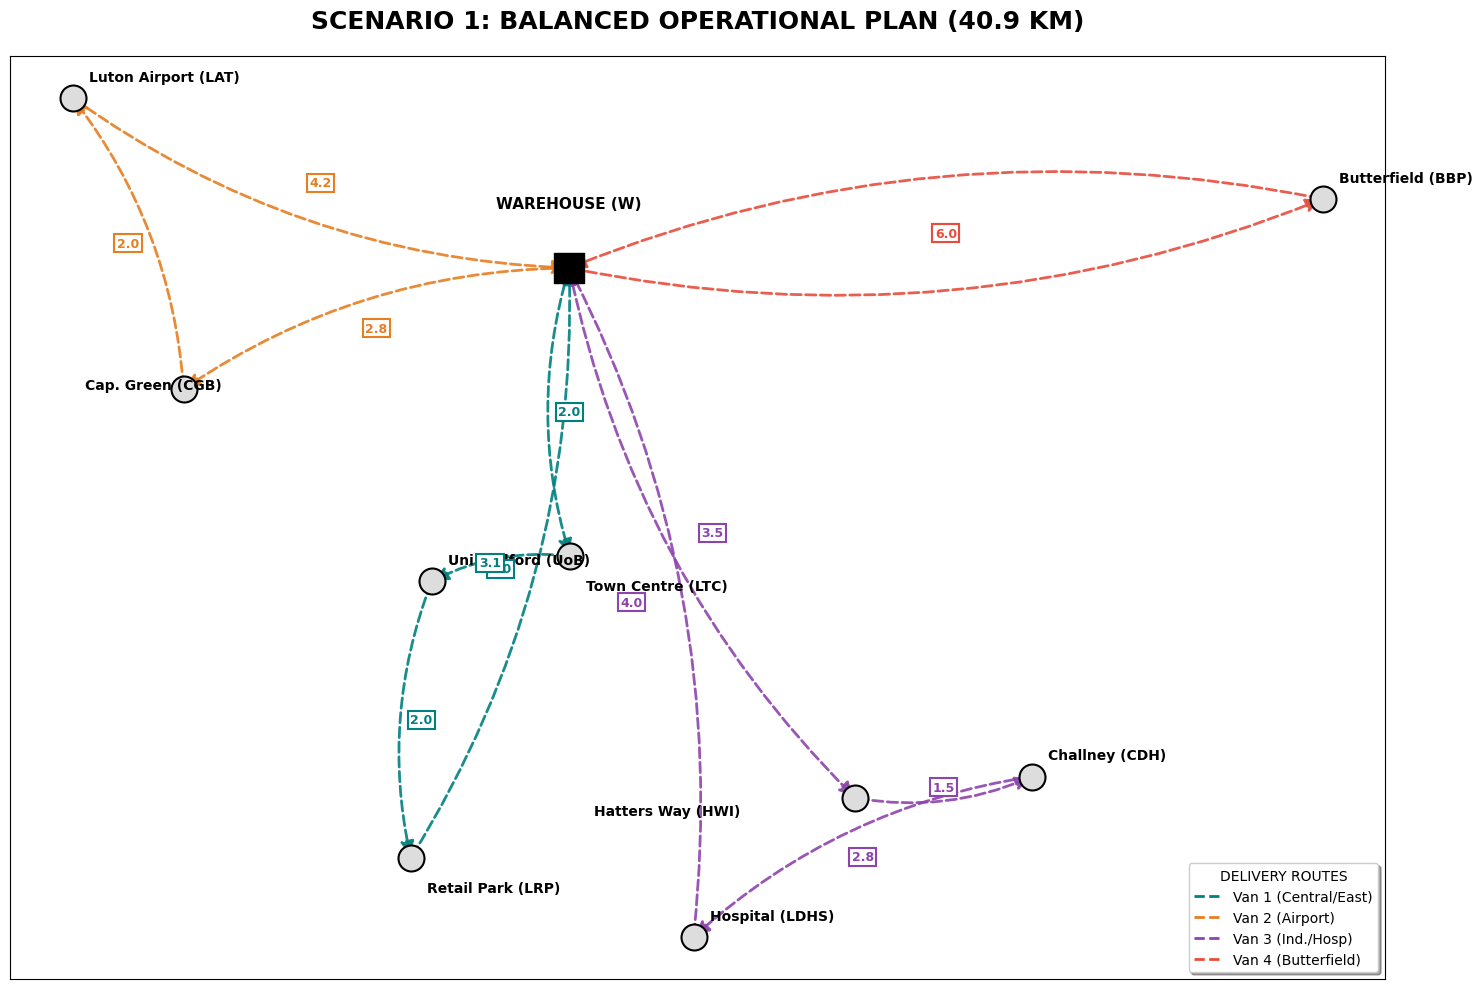

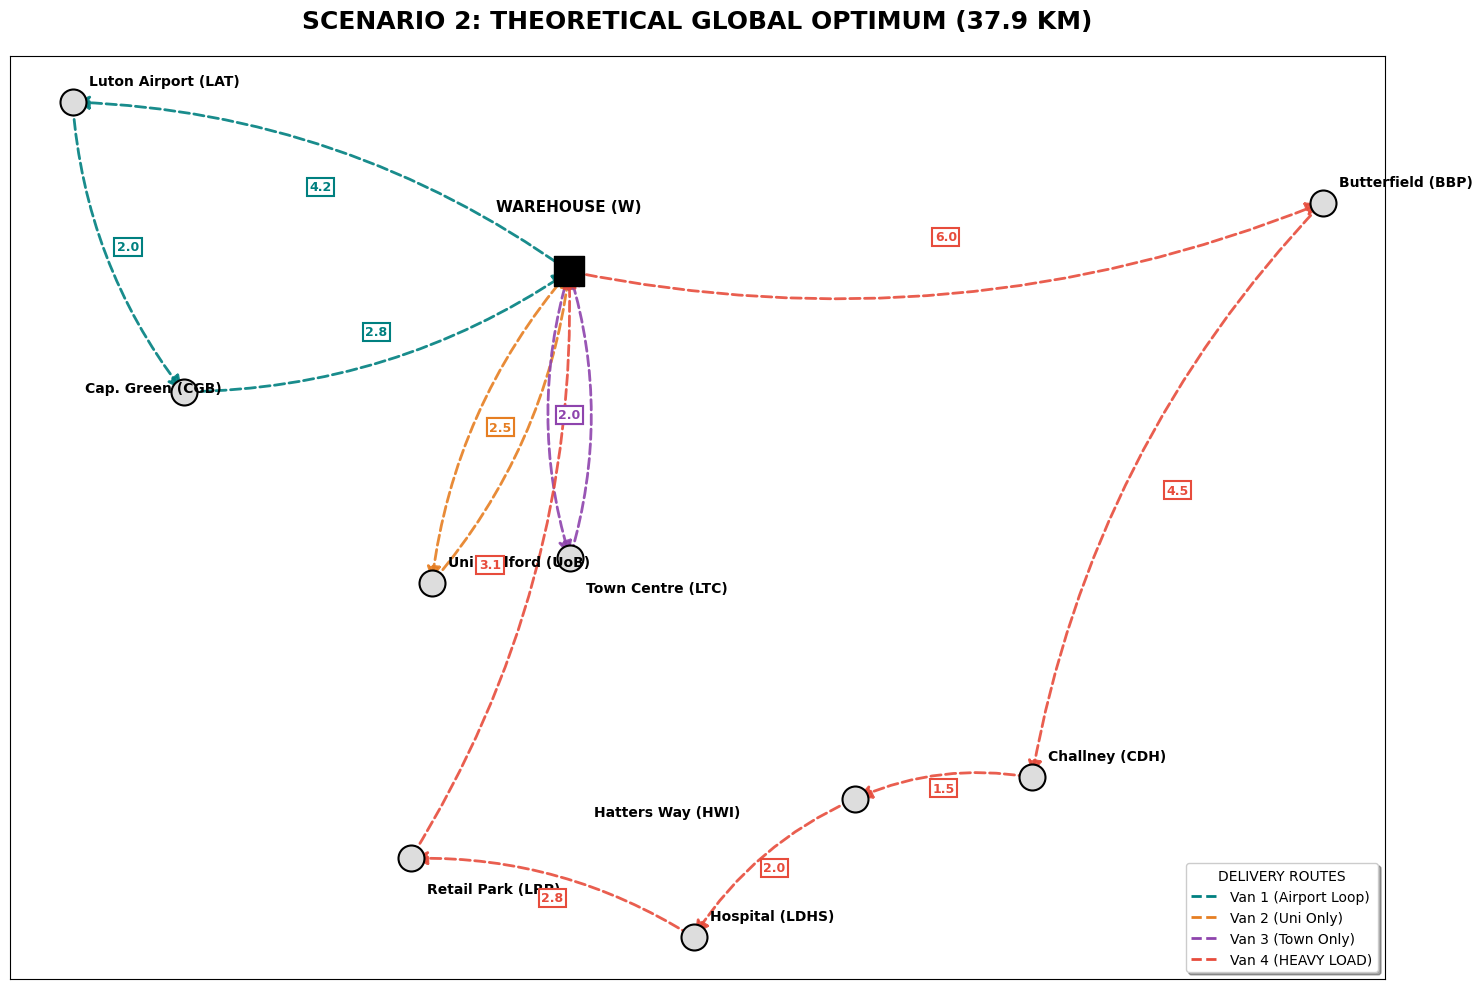

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from matplotlib.patches import FancyArrowPatch

# --- 1. Data ---
locations = [
    "Warehouse (W)", "Luton Airport (LAT)", "Uni Bedford (UoB)",
    "Retail Park (LRP)", "Cap. Green (CGB)", "Hospital (LDHS)",
    "Town Centre (LTC)", "Hatters Way (HWI)", "Challney (CDH)", "Butterfield (BBP)"
]

distance_matrix = np.array([
    [0,   4.2, 2.5, 3.1, 2.8, 4.0, 2.0, 3.5, 4.1, 6.0],
    [4.2, 0,   3.8, 5.0, 2.0, 5.5, 4.5, 6.0, 6.5, 7.2],
    [2.5, 3.8, 0,   2.0, 2.5, 3.0, 1.0, 3.2, 4.0, 5.5],
    [3.1, 5.0, 2.0, 0,   3.5, 2.8, 2.2, 2.5, 3.8, 6.2],
    [2.8, 2.0, 2.5, 3.5, 0,   4.0, 3.0, 4.5, 5.0, 6.8],
    [4.0, 5.5, 3.0, 2.8, 4.0, 0,   2.5, 2.0, 2.8, 5.0],
    [2.0, 4.5, 1.0, 2.2, 3.0, 2.5, 0,   2.8, 3.5, 5.2],
    [3.5, 6.0, 3.2, 2.5, 4.5, 2.0, 2.8, 0,   1.5, 4.8],
    [4.1, 6.5, 4.0, 3.8, 5.0, 2.8, 3.5, 1.5, 0,   4.5],
    [6.0, 7.2, 5.5, 6.2, 6.8, 5.0, 5.2, 4.8, 4.5, 0]
])

# --- 2. CREATE COORDINATES (FIXED) ---
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=1, max_iter=3000, eps=1e-9)
coords = mds.fit_transform(distance_matrix)

# Dictionary adjust label position (Manual tweaks) to avoid overlap
label_offsets = {
    0: (0.1, -0.3), 1: (0.1, 0.1), 2: (0.1, 0.1), 3: (0.1, -0.2),
    4: (-0.6, 0.0), 5: (0.1, 0.1), 6: (0.1, -0.2), 7: (-1.6, -0.1),
    8: (0.1, 0.1), 9: (0.1, 0.1)
}

# --- ARCS CURVE FUNCTION ---
def draw_network_map(routes, title_text, filename):
    fig, ax = plt.subplots(figsize=(15, 10))
    # ax.set_aspect('equal') # Giữ tỉ lệ chuẩn nếu cần

    # 1. Drawing Nodes - Bottom Layer
    ax.scatter(coords[:, 0], coords[:, 1], c='#DDDDDD', s=350, zorder=10, edgecolors='black', linewidth=1.5)
    ax.scatter(coords[0, 0], coords[0, 1], c='black', s=450, marker='s', zorder=11) # Warehouse

    # 2. Place name
    for i, txt in enumerate(locations):
        if "Warehouse" in txt: continue
        ox, oy = label_offsets.get(i, (0.15, 0.15))
        ax.annotate(txt, (coords[i, 0] + ox, coords[i, 1] + oy), fontsize=10, weight='bold', zorder=20)

    # Private Label for Warehouse
    ax.annotate("WAREHOUSE (W)", (coords[0, 0], coords[0, 1] + 0.35), fontsize=11, weight='bold', ha='center', zorder=20)

    # 3.Curved Arrows
    colors = ['#008080', '#E67E22', '#8E44AD', '#E74C3C'] # Teal, Orange, Purple, Red

    for idx, (name, path) in enumerate(routes.items()):
        color = colors[idx]

        # Browse each stage
        for j in range(len(path)-1):
            start_node = path[j]
            end_node = path[j+1]

            # Coordinates of start and end points
            p1 = coords[start_node]
            p2 = coords[end_node]

            # Calculate Curvature
            # rad=0.2 creates a gentle curve. Change the (+/-) sign to reverse the curve if desired
            # Here, keep rad=0.15 for a nice, even look
            connection_style = f"arc3,rad=0.15"

            # Draw curved arrows
            arrow = FancyArrowPatch(posA=p1, posB=p2,
                                    connectionstyle=connection_style,
                                    color=color, linewidth=2, linestyle='--',
                                    arrowstyle='-|>,head_length=8,head_width=4',
                                    zorder=5, alpha=0.9) # zorder low to be below text
            ax.add_patch(arrow)

            # --- KM GEARBOX DRAWING ---
            # Calculate the midpoint of the curve (approximately by the midpoint of the line + a little offset)
            mid_x = (p1[0] + p2[0]) / 2
            mid_y = (p1[1] + p2[1]) / 2

            dist_val = distance_matrix[start_node][end_node]

            # Draw text box with high zorder (zorder=30) -> Overlap all lines
            ax.text(mid_x, mid_y, f"{dist_val}",
                    fontsize=9, color=color, weight='bold', ha='center', va='center',
                    bbox=dict(boxstyle="square,pad=0.2", fc="white", ec=color, lw=1.5),
                    zorder=30)

    # Fake legend (because FancyArrowPatch doesn't support automatic legends well)
    # Draw fake lines outside the frame to create Legend
    for idx, (name, _) in enumerate(routes.items()):
        ax.plot([], [], color=colors[idx], linestyle='--', linewidth=2, label=name)

    ax.set_title(title_text, fontsize=18, weight='bold', pad=20)
    ax.legend(loc='lower right', title="DELIVERY ROUTES", fontsize=10, fancybox=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.3)

    # Hide coordinate axes for cleanliness
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# --- DRAW 2 SCENARIO ---

# SCENARIO 1: 40.9 KM
routes_1 = {
    "Van 1 (Central/East)": [0, 6, 2, 3, 0],
    "Van 2 (Airport)": [0, 4, 1, 0],
    "Van 3 (Ind./Hosp)":[0, 7, 8, 5, 0],
    "Van 4 (Butterfield)":  [0, 9, 0]
}
draw_network_map(routes_1, "SCENARIO 1: BALANCED OPERATIONAL PLAN (40.9 KM)", "Scenario1.png")

# SCENARIO 2: 37.9 KM
routes_2 = {
    "Van 1 (Airport Loop)": [0, 1, 4, 0],
    "Van 2 (Uni Only)":     [0, 2, 0],
    "Van 3 (Town Only)":    [0, 6, 0],
    "Van 4 (HEAVY LOAD)":   [0, 9, 8, 7, 5, 3, 0]
}
draw_network_map(routes_2, "SCENARIO 2: THEORETICAL GLOBAL OPTIMUM (37.9 KM)", "Scenario2.png")